# 08 - Calidad de bases analíticas ENIGH 2018-2024

Esta libreta audita la calidad de las dos bases preparadas para análisis antes de avanzar a desigualdad territorial, Gini, deflactación o modelos.

Terminología:

- `mart_persona` = **Base analítica de personas**.
- `mart_hogar` = **Base analítica de hogares**.
- Un *data mart* es solo el nombre técnico de una tabla preparada para análisis a una granularidad específica.

En la narrativa se usa preferentemente **base analítica de personas** y **base analítica de hogares**, aunque los archivos conserven sus nombres técnicos.

La auditoría se concentra en faltantes, ceros, universos aplicables y decisiones provisionales. No se imputa, no se eliminan filas, no se reconstruyen bases y no se ajustan modelos sustantivos.

In [1]:
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 13, "axes.labelsize": 11})

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "interim" / "revision_4").exists():
            return candidate
    raise FileNotFoundError("No se encontró data/interim/revision_4 desde el directorio actual.")

ROOT = find_project_root()
REV4 = ROOT / "data" / "interim" / "revision_4"
PERSONA_PATH = REV4 / "mart_persona_2018_2024.csv.gz"
HOGAR_PATH = REV4 / "mart_hogar_2018_2024.csv.gz"
SUMMARY_PATH = REV4 / "resumen_revision_4_marts.json"
YEARS = [2018, 2020, 2022, 2024]

TARGET_LABOR = "ingreso_persona_laboral_negocio_tri"
TARGET_PERSON_TOTAL = "ingreso_persona_total_registros_tri"
TARGET_HH_CURRENT_PERSON = "ing_cor_hogar_pc_oficial_tri"
TARGET_HH_CURRENT = "ing_cor_hogar_oficial_tri"
TARGET_HH_CURRENT_PC = "ing_cor_pc_oficial_tri"
WEIGHT = "factor"

print(f"Proyecto: {ROOT}")
print(f"Base analítica de personas: {PERSONA_PATH.exists()} | {PERSONA_PATH}")
print(f"Base analítica de hogares: {HOGAR_PATH.exists()} | {HOGAR_PATH}")

Proyecto: C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-income-modeling
Base analítica de personas: True | C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-income-modeling\data\interim\revision_4\mart_persona_2018_2024.csv.gz
Base analítica de hogares: True | C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-income-modeling\data\interim\revision_4\mart_hogar_2018_2024.csv.gz


## Construcción real de las bases

Las bases actuales se construyeron en `notebooks/05_bases_analiticas.ipynb` y se guardaron en `data/interim/revision_4`. No se reconstruyen en esta libreta.

**Base analítica de personas**

```text
POBLACION
    |
    +-- INGRESOS agregados a nivel persona
    |
    +-- TRABAJOS agregados a nivel persona
    |
    +-- CONCENTRADOHOGAR: ingreso oficial del hogar, diseño muestral y geografía
    |
    +-- HOGARES: servicios y características del hogar
    |
    +-- VIVIENDAS: características de vivienda
    |
    v
1 fila = 1 persona x año
Llave = anio + folioviv + foliohog + numren
```

**Base analítica de hogares**

```text
CONCENTRADOHOGAR
    |
    +-- HOGARES
    |
    +-- VIVIENDAS
    |
    +-- POBLACION agregada a nivel hogar
    |
    +-- INGRESOS agregados a nivel hogar desde ingresos.csv
    |
    v
1 fila = 1 hogar x año
Llave = anio + folioviv + foliohog
```

Las observaciones de 2018, 2020, 2022 y 2024 están concatenadas. No es un panel: una persona u hogar de 2018 y una persona u hogar de 2024 son observaciones independientes de levantamientos distintos.

In [2]:
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8")) if SUMMARY_PATH.exists() else {}
resumen_bases = pd.DataFrame([
    {"base_analitica":"personas", **summary.get("mart_persona", {})},
    {"base_analitica":"hogares", **summary.get("mart_hogar", {})},
])
display(resumen_bases)

validacion_persona = pd.read_csv(REV4 / "validacion_mart_persona.csv")
validacion_hogar = pd.read_csv(REV4 / "validacion_mart_hogar.csv")
display(Markdown("### Validación de integración: base analítica de personas")); display(validacion_persona)
display(Markdown("### Validación de integración: base analítica de hogares")); display(validacion_hogar)

,base_analitica,archivo,filas,columnas,llave,duplicados_llave,region_banxico_faltantes,factor_faltantes
0,personas,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...,1203231,140,"[anio, folioviv, foliohog, numren]",0,0,0
1,hogares,C:\Users\lucia\OneDrive\Escritorio\Fer\inegi-i...,345169,92,"[anio, folioviv, foliohog]",0,0,0


### Validación de integración: base analítica de personas

,paso,filas_antes,filas_despues,duplicados_llave_derecha,duplicados_llave_mart,matches,pct_match,tipo
0,Agregar ingresos a nivel persona,1203231,1203231,0,0,794275,66.0118,opcional
1,Agregar trabajos a nivel persona,1203231,1203231,0,0,578089,48.0447,opcional
2,Agregar hogar/concentrado/geografía,1203231,1203231,0,0,1203231,100.0000,esperado
3,Agregar variables de hogares,1203231,1203231,0,0,1203231,100.0000,esperado
4,Agregar vivienda,1203231,1203231,0,0,1203231,100.0000,esperado


### Validación de integración: base analítica de hogares

,paso,filas_antes,filas_despues,duplicados_llave_derecha,duplicados_llave_mart,matches,pct_match,tipo
0,Agregar variables de hogares,345169,345169,0,0,345169,100.0000,esperado
1,Agregar vivienda,345169,345169,0,0,345169,100.0000,esperado
2,Agregar agregados de población,345169,345169,0,0,345169,100.0000,esperado
3,Agregar ingresos derivados de ingresos.csv,345169,345169,0,0,344919,99.9276,opcional


## Variables prioritarias reales

El inventario global se calcula para todas las columnas. El diagnóstico interpretativo se enfoca en variables candidatas para análisis regional, desigualdad, ingreso y modelado posterior.

In [3]:
def available_columns(path):
    return pd.read_csv(path, nrows=0).columns.tolist()

persona_available = available_columns(PERSONA_PATH)
hogar_available = available_columns(HOGAR_PATH)

PERSONA_PRIORITY = [
    "anio","folioviv","foliohog","numren","factor","factor_hogar","est_dis","upm",
    "edad","sexo_desc","edo_conyug_desc","segsoc_desc","asis_esc","asis_esc_desc","nivel_desc","nivelaprob_desc","grado","gradoaprob",
    "trabajo_mp","motivo_aus_desc","act_pnea1_desc","act_pnea2_desc","num_trabaj_desc","tiene_trabajo_reportado","n_trabajos","horas_trabajos_total","horas_trabajo_principal",
    "subor_principal_desc","indep_principal_desc","pago_principal_desc","contrato_principal_desc","tiene_suel_principal_desc","tam_emp_principal_desc",
    "registros_ingreso","claves_ingreso_distintas",TARGET_PERSON_TOTAL,TARGET_LABOR,"ingreso_persona_transferencias_tri","ingreso_persona_rentas_propiedad_tri","ingreso_persona_financiero_capital_tri","ingreso_persona_no_clasificado_tri",
    "tot_integ","hombres","mujeres","mayores","menores","p12_64","p65mas","ocupados","percep_ing","perc_ocupa",TARGET_HH_CURRENT_PERSON,"ingtrab_hogar_pc_oficial_tri",
    "region_banxico","entidad","cve_ent","tam_loc_desc","est_socio_desc",
]
HOGAR_PRIORITY = [
    "anio","folioviv","foliohog","factor","factor_hogar","est_dis","upm",TARGET_HH_CURRENT,"ingtrab_hogar_oficial_tri","trabajo_subordinado_hogar_tri","sueldos_hogar_tri","negocio_hogar_tri","rentas_hogar_tri","transfer_hogar_tri","otros_ing_hogar_tri","gasto_mon_hogar_tri",TARGET_HH_CURRENT_PC,"ingtrab_pc_oficial_tri",
    "personas_con_registros_ingreso","ingreso_personas_total_registros_tri","ingreso_personas_laboral_negocio_tri","ingreso_personas_transferencias_tri","ingreso_personas_rentas_propiedad_tri","ingreso_personas_financiero_capital_tri",
    "tot_integ","hombres","mujeres","mayores","menores","p12_64","p65mas","ocupados","percep_ing","perc_ocupa","prop_ocupados_oficial","n_personas_calc","n_menores_18_calc","n_mayores_65_calc","edad_promedio_calc","edad_jefe","sexo_jefe_desc","educa_jefe_desc","nivelaprob_jefe_desc","clase_hog_desc","region_banxico","entidad","cve_ent","tam_loc_desc","est_socio_desc",
]

persona_cols = [c for c in PERSONA_PRIORITY if c in persona_available]
hogar_cols = [c for c in HOGAR_PRIORITY if c in hogar_available]
print("Variables prioritarias no disponibles en personas:", [c for c in PERSONA_PRIORITY if c not in persona_available])
print("Variables prioritarias no disponibles en hogares:", [c for c in HOGAR_PRIORITY if c not in hogar_available])

persona = pd.read_csv(PERSONA_PATH, usecols=persona_cols, low_memory=False)
hogar = pd.read_csv(HOGAR_PATH, usecols=hogar_cols, low_memory=False)

numeric_persona = ["anio","edad","grado","gradoaprob","trabajo_mp","n_trabajos","horas_trabajos_total","horas_trabajo_principal","registros_ingreso","claves_ingreso_distintas",TARGET_PERSON_TOTAL,TARGET_LABOR,"ingreso_persona_transferencias_tri","ingreso_persona_rentas_propiedad_tri","ingreso_persona_financiero_capital_tri","ingreso_persona_no_clasificado_tri","tot_integ","hombres","mujeres","mayores","menores","p12_64","p65mas","ocupados","percep_ing","perc_ocupa",TARGET_HH_CURRENT_PERSON,"ingtrab_hogar_pc_oficial_tri","factor","factor_hogar"]
numeric_hogar = ["anio",TARGET_HH_CURRENT,"ingtrab_hogar_oficial_tri","trabajo_subordinado_hogar_tri","sueldos_hogar_tri","negocio_hogar_tri","rentas_hogar_tri","transfer_hogar_tri","otros_ing_hogar_tri","gasto_mon_hogar_tri",TARGET_HH_CURRENT_PC,"ingtrab_pc_oficial_tri","personas_con_registros_ingreso","ingreso_personas_total_registros_tri","ingreso_personas_laboral_negocio_tri","ingreso_personas_transferencias_tri","ingreso_personas_rentas_propiedad_tri","ingreso_personas_financiero_capital_tri","tot_integ","hombres","mujeres","mayores","menores","p12_64","p65mas","ocupados","percep_ing","perc_ocupa","prop_ocupados_oficial","n_personas_calc","n_menores_18_calc","n_mayores_65_calc","edad_promedio_calc","edad_jefe","factor","factor_hogar"]
for col in numeric_persona:
    if col in persona.columns: persona[col] = pd.to_numeric(persona[col], errors="coerce")
for col in numeric_hogar:
    if col in hogar.columns: hogar[col] = pd.to_numeric(hogar[col], errors="coerce")

def as_bool(series):
    if series.dtype == bool: return series.fillna(False)
    return series.astype("string").str.lower().str.strip().isin(["true","1","sí","si"])

persona["grupo_edad"] = pd.cut(persona["edad"], bins=[-1,5,11,17,29,44,64,200], labels=["0-5","6-11","12-17","18-29","30-44","45-64","65+"])
trabajadores = as_bool(persona["tiene_trabajo_reportado"])
subordinados = persona["subor_principal_desc"].eq("Sí")
no_subordinados = persona["subor_principal_desc"].eq("No")
recibe_pago = persona["pago_principal_desc"].eq("Recibe un pago")
asiste_escuela = persona["asis_esc_desc"].eq("Sí")
ingreso_laboral_positivo = persona[TARGET_LABOR].gt(0)
ingreso_registrado = persona["registros_ingreso"].gt(0)
personas_6_mas = persona["edad"].ge(6)
personas_12_mas = persona["edad"].ge(12)
print("personas", persona.shape, "hogares", hogar.shape)

Variables prioritarias no disponibles en personas: []
Variables prioritarias no disponibles en hogares: []
personas (1203231, 59) hogares (345169, 49)


## Acumulación temporal

La tabla confirma que las bases son una acumulación de levantamientos independientes. No seguimos a las mismas personas u hogares a través del tiempo.

,Base analítica,2018,2020,2022,2024,Total
0,Personas,269206,315743,309684,308598,1203231
1,Hogares,74647,89006,90102,91414,345169


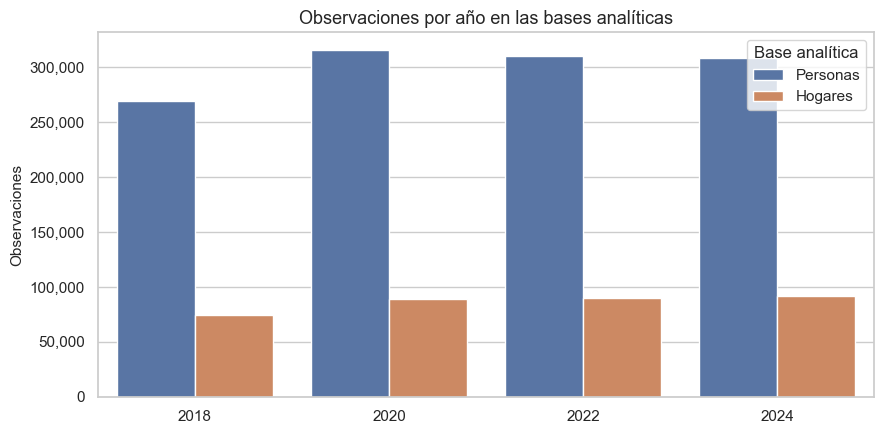

In [4]:
def temporal_distribution(df, label):
    counts = df.groupby("anio").size().reindex(YEARS, fill_value=0)
    return {"Base analítica": label, **{int(y): int(counts.loc[y]) for y in YEARS}, "Total": int(counts.sum())}

temporal_table = pd.DataFrame([temporal_distribution(persona,"Personas"), temporal_distribution(hogar,"Hogares")])
display(temporal_table)
fig, ax = plt.subplots(figsize=(9,4.5))
temporal_long = temporal_table.melt(id_vars="Base analítica", value_vars=YEARS, var_name="Año", value_name="Observaciones")
sns.barplot(data=temporal_long, x="Año", y="Observaciones", hue="Base analítica", ax=ax)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
ax.set_title("Observaciones por año en las bases analíticas"); ax.set_xlabel(""); ax.set_ylabel("Observaciones")
fig.tight_layout(); display(fig); plt.close(fig)

## Inventario global de faltantes

Se revisan todas las columnas por fragmentos para no cargar la base completa de personas en memoria. El inventario global se concentra en faltantes total y por año; los ceros y valores únicos exactos se calculan en el inventario prioritario, que es el que se interpreta para decisiones analíticas.

In [5]:
def missing_bucket(pct):
    if pct == 0: return "0%"
    if pct <= 5: return ">0-5%"
    if pct <= 20: return ">5-20%"
    if pct <= 50: return ">20-50%"
    if pct <= 90: return ">50-90%"
    return ">90%"

def zero_like(series):
    numeric = pd.to_numeric(series, errors="coerce")
    text = series.astype("string").str.strip().str.lower()
    return numeric.eq(0) | text.isin(["0","0.0","false"])

def inventory_csv(path, base_label, chunksize=200_000):
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    total = {c:{"N":0,"missing":0,"zero":0,"zero_applicable":False} for c in cols}
    by_year = {}
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        numeric_cols = set(chunk.select_dtypes(include="number").columns)
        for c in cols:
            s = chunk[c]
            total[c]["N"] += int(len(s))
            total[c]["missing"] += int(s.isna().sum())
            if c in numeric_cols:
                total[c]["zero"] += int(s.eq(0).sum())
                total[c]["zero_applicable"] = True
        for y, sub in chunk.groupby("anio", dropna=False):
            ykey = int(y) if pd.notna(y) else "sin_anio"
            numeric_sub = set(sub.select_dtypes(include="number").columns)
            for c in cols:
                st = by_year.setdefault((ykey,c), {"N":0,"missing":0,"zero":0,"zero_applicable":False})
                s = sub[c]
                st["N"] += int(len(s)); st["missing"] += int(s.isna().sum())
                if c in numeric_sub:
                    st["zero"] += int(s.eq(0).sum()); st["zero_applicable"] = True
    def rows(obj, include_year=False):
        out=[]
        for key, st in obj.items():
            if include_year: y, c = key
            else: y, c = None, key
            mp = st["missing"] / st["N"] * 100 if st["N"] else np.nan
            zp = st["zero"] / st["N"] * 100 if st["zero_applicable"] and st["N"] else np.nan
            row = {"base":base_label, "variable":c, "N":st["N"], "n_missing":st["missing"], "missing_pct":round(mp,4), "rango_missing":missing_bucket(round(mp,10)), "n_cero":st["zero"] if st["zero_applicable"] else np.nan, "cero_pct":round(zp,4) if pd.notna(zp) else np.nan}
            if include_year: row["anio"] = y
            out.append(row)
        return out
    return pd.DataFrame(rows(total)), pd.DataFrame(rows(by_year, include_year=True))

inventory_persona, inventory_year_persona = inventory_csv(PERSONA_PATH, "Personas")
inventory_hogar, inventory_year_hogar = inventory_csv(HOGAR_PATH, "Hogares")
inventory_total = pd.concat([inventory_persona, inventory_hogar], ignore_index=True)
inventory_year = pd.concat([inventory_year_persona, inventory_year_hogar], ignore_index=True)

display(Markdown("### Resumen por rangos de missing"))
display(inventory_total.groupby(["base","rango_missing"]).size().reset_index(name="variables"))
display(Markdown("### Variables con mayor porcentaje de missing"))
display(inventory_total.sort_values(["missing_pct","cero_pct"], ascending=False).head(30))

### Resumen por rangos de missing

,base,rango_missing,variables
0,Hogares,0%,88
1,Hogares,>20-50%,2
2,Hogares,>5-20%,2
3,Personas,0%,93
4,Personas,>0-5%,11
5,Personas,>20-50%,2
6,Personas,>5-20%,9
7,Personas,>50-90%,20
8,Personas,>90%,5


### Variables con mayor porcentaje de missing

,base,variable,N,n_missing,missing_pct,rango_missing,n_cero,cero_pct
20,Personas,motivo_aus,1203231,1198868,99.6374,>90%,0.0,0.0
31,Personas,motivo_aus_desc,1203231,1198868,99.6374,>90%,NaN,NaN
22,Personas,act_pnea2,1203231,1186177,98.5826,>90%,0.0,0.0
25,Personas,act_pnea2_desc,1203231,1186177,98.5826,>90%,NaN,NaN
8,Personas,lenguaind,1203231,1124343,93.4437,>90%,0.0,0.0
60,Personas,tiene_suel_principal,1203231,1069269,88.8665,>50-90%,0.0,0.0
61,Personas,tiene_suel_principal_desc,1203231,1069269,88.8665,>50-90%,NaN,NaN
54,Personas,indep_principal,1203231,1066620,88.6463,>50-90%,0.0,0.0
55,Personas,indep_principal_desc,1203231,1066620,88.6463,>50-90%,NaN,NaN
13,Personas,grado,1203231,869297,72.2469,>50-90%,0.0,0.0


## Inventario prioritario y heatmap de faltantes

La matriz variable x año se limita a variables prioritarias para detectar cambios bruscos o patrones longitudinales sin hacer una gráfica ilegible.

,base,variable,N,n_missing,missing_pct,rango_missing,n_cero,cero_pct,n_unicos
19,Personas,motivo_aus_desc,1203231,1198868,99.6374,>90%,0,0.0000,16
21,Personas,act_pnea2_desc,1203231,1186177,98.5826,>90%,0,0.0000,4
31,Personas,tiene_suel_principal_desc,1203231,1069269,88.8665,>50-90%,0,0.0000,2
28,Personas,indep_principal_desc,1203231,1066620,88.6463,>50-90%,0,0.0000,2
16,Personas,grado,1203231,869297,72.2469,>50-90%,0,0.0000,6
14,Personas,nivel_desc,1203231,869288,72.2461,>50-90%,0,0.0000,19
20,Personas,act_pnea1_desc,1203231,811739,67.4633,>50-90%,0,0.0000,7
30,Personas,contrato_principal_desc,1203231,788877,65.5632,>50-90%,0,0.0000,2
29,Personas,pago_principal_desc,1203231,759104,63.0888,>50-90%,0,0.0000,3
22,Personas,num_trabaj_desc,1203231,625142,51.9553,>50-90%,0,0.0000,3


,base,variable,N,n_missing,missing_pct,rango_missing,n_cero,cero_pct,n_unicos
14,Hogares,otros_ing_hogar_tri,345169,0,0.0,0%,338418,98.0441,1573
22,Hogares,ingreso_personas_rentas_propiedad_tri,345169,0,0.0,0%,330060,95.6227,1982
12,Hogares,rentas_hogar_tri,345169,0,0.0,0%,318279,92.2096,12263
23,Hogares,ingreso_personas_financiero_capital_tri,345169,0,0.0,0%,270536,78.3778,8463
30,Hogares,p65mas,345169,0,0.0,0%,258242,74.8161,6
37,Hogares,n_mayores_65_calc,345169,0,0.0,0%,258234,74.8138,6
11,Hogares,negocio_hogar_tri,345169,0,0.0,0%,241127,69.8577,52170
28,Hogares,menores,345169,0,0.0,0%,201845,58.4772,12
36,Hogares,n_menores_18_calc,345169,0,0.0,0%,156565,45.3589,14
21,Hogares,ingreso_personas_transferencias_tri,345169,0,0.0,0%,148973,43.1594,32098


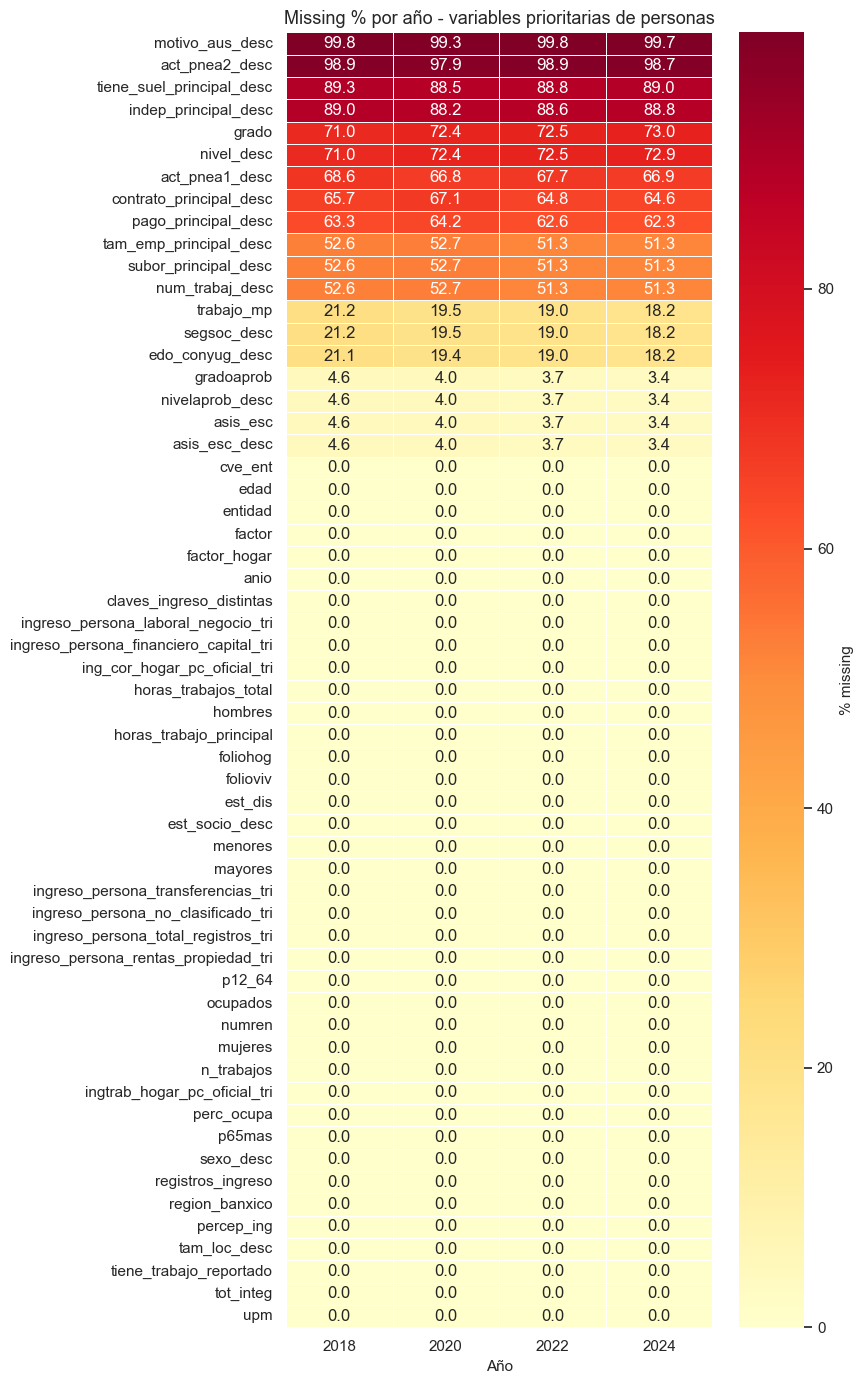

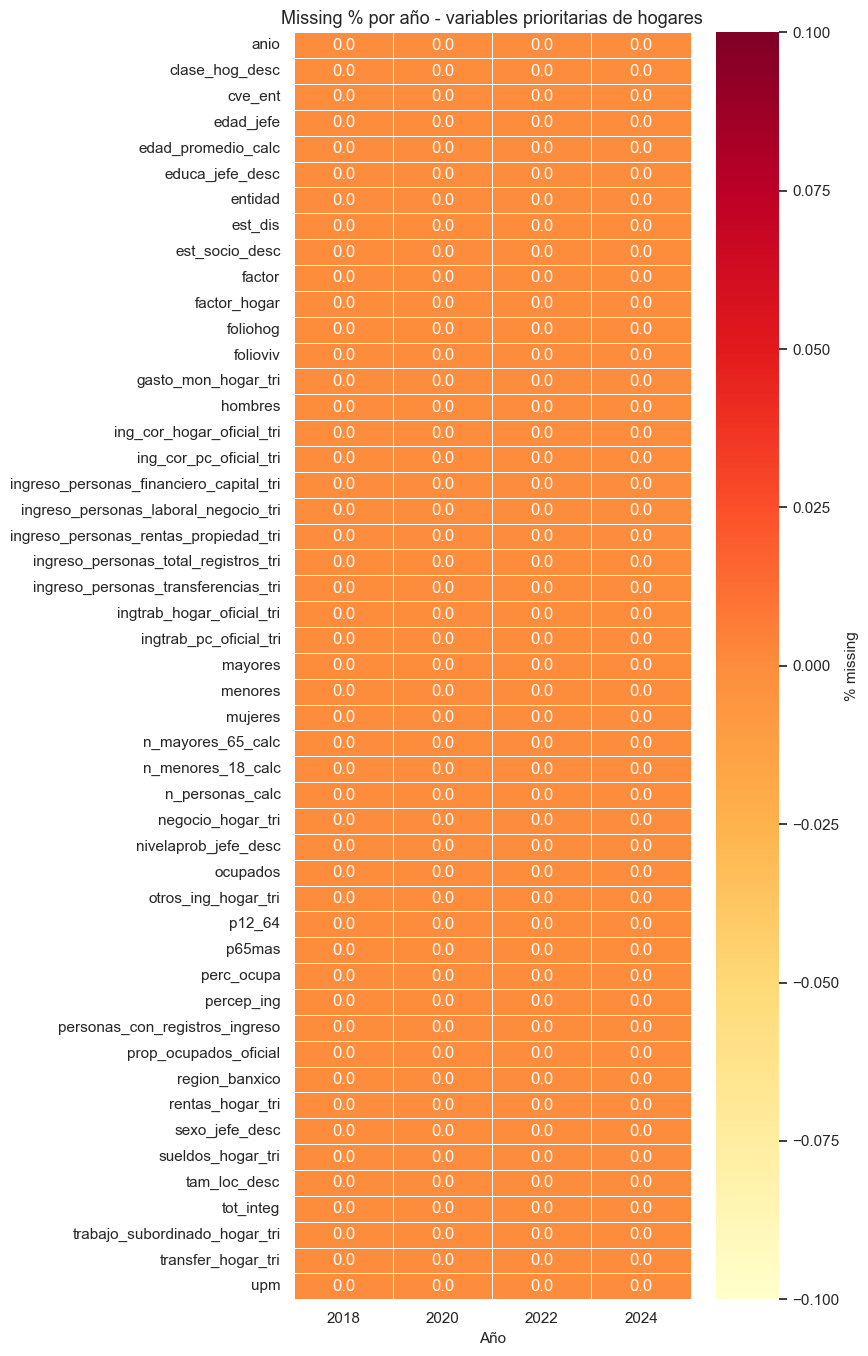

In [6]:
def inventory_loaded(df, base_label, variables):
    rows=[]
    for var in variables:
        if var not in df.columns:
            continue
        s = df[var]
        z = zero_like(s)
        rows.append({"base":base_label, "variable":var, "N":len(s), "n_missing":int(s.isna().sum()), "missing_pct":round(float(s.isna().mean()*100),4), "rango_missing":missing_bucket(round(float(s.isna().mean()*100),10)), "n_cero":int(z.sum()), "cero_pct":round(float(z.mean()*100),4), "n_unicos":int(s.nunique(dropna=True))})
    return pd.DataFrame(rows)

priority_inventory_persona = inventory_loaded(persona, "Personas", persona_cols)
priority_inventory_hogar = inventory_loaded(hogar, "Hogares", hogar_cols)
display(priority_inventory_persona.sort_values(["missing_pct","cero_pct"], ascending=False))
display(priority_inventory_hogar.sort_values(["missing_pct","cero_pct"], ascending=False))

def heatmap_missing(base_label, variables, title):
    data = inventory_year.loc[inventory_year["base"].eq(base_label) & inventory_year["variable"].isin(variables)].copy()
    pivot = data.pivot_table(index="variable", columns="anio", values="missing_pct", aggfunc="first")
    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(8.5, max(5, min(14, 0.28 * len(pivot)))))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.4, cbar_kws={"label":"% missing"}, ax=ax)
    ax.set_title(title); ax.set_xlabel("Año"); ax.set_ylabel("")
    fig.tight_layout(); display(fig); plt.close(fig)
heatmap_missing("Personas", persona_cols, "Missing % por año - variables prioritarias de personas")
heatmap_missing("Hogares", hogar_cols, "Missing % por año - variables prioritarias de hogares")

## Universos aplicables

Antes de evaluar mecanismos de missing se revisa si la variable debería aplicar a todas las observaciones. Si el faltante desaparece al filtrar el universo correcto, se trata como faltante estructural / no aplica.

In [7]:
PERSONA_UNIVERSES = {
    "todas_personas": pd.Series(True, index=persona.index),
    "personas_6_mas": personas_6_mas,
    "personas_12_mas": personas_12_mas,
    "asiste_escuela": asiste_escuela,
    "trabajadores": trabajadores,
    "trabajadores_subordinados": trabajadores & subordinados,
    "trabajadores_no_subordinados": trabajadores & no_subordinados,
    "trabajadores_con_pago": trabajadores & recibe_pago,
    "ingreso_laboral_positivo": ingreso_laboral_positivo,
    "registro_ingreso_positivo": ingreso_registrado,
}
HOGAR_UNIVERSES = {"todos_hogares": pd.Series(True, index=hogar.index)}
labels = {"todas_personas":"A. Base completa de personas", "trabajadores":"B. Personas con trabajo reportado", "ingreso_laboral_positivo":"C. Personas con ingreso laboral positivo", "todos_hogares":"D. Hogares", "personas_12_mas":"Personas de 12 años o más", "personas_6_mas":"Personas de 6 años o más", "trabajadores_subordinados":"Trabajadores subordinados", "trabajadores_no_subordinados":"Trabajadores no subordinados", "trabajadores_con_pago":"Trabajadores que reciben pago"}

def universe_counts(df, masks):
    rows=[]
    for key, mask in masks.items():
        counts = df.loc[mask].groupby("anio").size().reindex(YEARS, fill_value=0)
        rows.append({"Universo": labels.get(key,key), **{y:int(counts.loc[y]) for y in YEARS}, "Total":int(mask.sum())})
    return pd.DataFrame(rows)
universos = pd.concat([universe_counts(persona, PERSONA_UNIVERSES), universe_counts(hogar, HOGAR_UNIVERSES)], ignore_index=True)
display(universos)

,Universo,2018,2020,2022,2024,Total
0,A. Base completa de personas,269206,315743,309684,308598,1203231
1,Personas de 6 años o más,242619,287815,284000,284802,1099236
2,Personas de 12 años o más,212394,254343,250839,252527,970103
3,asiste_escuela,78198,87256,85012,83477,333943
4,B. Personas con trabajo reportado,127638,149387,150682,150382,578089
5,Trabajadores subordinados,98088,112283,115281,115826,441478
6,Trabajadores no subordinados,29550,37104,35401,34556,136611
7,Trabajadores que reciben pago,92324,103842,108984,109204,414354
8,C. Personas con ingreso laboral positivo,127846,148082,149569,148965,574462
9,registro_ingreso_positivo,182434,204332,205144,202365,794275


## Tabla interpretativa de mecanismos de missing

La clasificación usa el faltante total y el faltante dentro del universo aplicable. No se imputan valores.

In [8]:
def pct(n, d): return np.nan if d == 0 else n / d * 100

def get_base(base):
    return (persona, PERSONA_UNIVERSES) if base == "Personas" else (hogar, HOGAR_UNIVERSES)

QUALITY_DEFS = [
("Personas","Ingreso laboral",TARGET_LABOR,"todas_personas","sin_faltantes","Target derivado de ingresos.csv; cero identifica no tener ingreso laboral/negocio.","Analizar probabilidad de ingreso >0 y monto condicionado a >0.","cero_legitimo"),
("Personas","Ingreso total individual",TARGET_PERSON_TOTAL,"todas_personas","sin_faltantes","Sin NaN; ceros coinciden con ausencia de registros de ingreso agregados.","Usar directamente distinguiendo registros de ingreso.","cero_legitimo"),
("Personas","Ingreso corriente pc hogar",TARGET_HH_CURRENT_PERSON,"todas_personas","sin_faltantes","Derivado del ingreso oficial del hogar y total de integrantes.","Usar como contraste de bienestar del hogar.","cero_legitimo_con_cautela"),
("Personas","Registros de ingreso","registros_ingreso","todas_personas","sin_faltantes","Sin registro en ingresos.csv se codificó como 0.","Usar como indicador de presencia de ingresos registrados.","cero_estructural"),
("Personas","Edad","edad","todas_personas","sin_faltantes","Completa.","Usar directamente.","cero_legitimo"),
("Personas","Sexo","sexo_desc","todas_personas","sin_faltantes","Completa.","Usar directamente.","no_aplica"),
("Personas","Estado conyugal","edo_conyug_desc","personas_12_mas","estructural_no_aplica","Falta en 0-11 años; dentro de 12+ es 0%.","Usar solo para personas de 12 años o más.","no_aplica"),
("Personas","Asistencia escolar","asis_esc_desc","personas_6_mas","estructural_no_aplica","Faltante concentrado en 0-5; etiquetas de No corregidas por codigo 1=Si y 2=No.","Usar en personas de 6 anos o mas; no usar nivel_desc como escolaridad general.","no_aplica"),
("Personas","Nivel educativo actual","nivel_desc","asiste_escuela","estructural_no_aplica","Observado cuando la persona asiste a la escuela; falta si no asiste.","No usar como escolaridad general.","no_aplica"),
("Personas","Escolaridad aprobada","nivelaprob_desc","personas_6_mas","estructural_no_aplica","Faltante concentrado en 0-5; desde 6+ prácticamente desaparece.","Usar como variable educativa principal con cuidado en edad temprana.","no_aplica"),
("Personas","Seguridad social","segsoc_desc","personas_12_mas","estructural_no_aplica","Faltante bruto explicado casi totalmente por 0-11; residual mínimo en 12+.","Usar con universo 12+ y revisar residual si se vuelve central.","no_aplica"),
("Personas","Trabajo reportado","tiene_trabajo_reportado","todas_personas","sin_faltantes","Indicador derivado del merge de trabajos; completo.","Define elegibilidad laboral.","cero_estructural"),
("Personas","Número de trabajos","n_trabajos","todas_personas","sin_faltantes","0 indica ausencia de registro en trabajos.csv.","Usar como conteo; cero define no trabajo reportado.","cero_estructural"),
("Personas","Horas trabajo principal","horas_trabajo_principal","trabajadores","estructural_no_aplica","Ceros corresponden a no trabajadores; entre trabajadores no hay faltantes.","Usar solo en trabajadores.","cero_estructural"),
("Personas","Subordinación","subor_principal_desc","trabajadores","estructural_no_aplica","Falta para no trabajadores; dentro de trabajadores está completa.","Usar solo en trabajadores.","no_aplica"),
("Personas","Independencia","indep_principal_desc","trabajadores_no_subordinados","estructural_no_aplica","Falta para subordinados; observada en no subordinados.","Usar solo en no subordinados.","no_aplica"),
("Personas","Forma de pago","pago_principal_desc","trabajadores_subordinados","estructural_no_aplica","Completa en trabajadores subordinados; mayormente no aplica en no subordinados.","Usar con universo subordinado o documentar no aplica.","no_aplica"),
("Personas","Contrato","contrato_principal_desc","trabajadores_con_pago","estructural_no_aplica","Completa entre quienes reciben pago; no aplica fuera de esa ruta.","Usar solo para trabajadores con pago.","no_aplica"),
("Personas","Tamaño de empresa","tam_emp_principal_desc","trabajadores","estructural_no_aplica","Falta para no trabajadores; dentro de trabajadores está completa.","Usar solo en trabajadores.","no_aplica"),
("Personas","Región Banxico","region_banxico","todas_personas","sin_faltantes","32 entidades clasificadas sin faltantes.","Usar directamente.","no_aplica"),
("Personas","Tamaño localidad","tam_loc_desc","todas_personas","sin_faltantes","Completa.","Usar directamente.","no_aplica"),
("Personas","Estrato socioeconómico","est_socio_desc","todas_personas","sin_faltantes","Completa; etiqueta 2022 normalizada por código en etapa previa.","Usar directamente.","no_aplica"),
("Personas","Factor expansión","factor","todas_personas","sin_faltantes","Completo; alias de factor_hogar heredado desde concentradohogar.","Usar para descriptivos ponderados; diseño complejo queda para otra etapa.","no_aplica"),
("Personas","Estrato diseño","est_dis","todas_personas","sin_faltantes","Completa.","Conservar para inferencia posterior.","cero_codigo"),
("Personas","UPM","upm","todas_personas","sin_faltantes","Completa.","Conservar para inferencia posterior.","cero_codigo"),
("Hogares","Ingreso corriente hogar",TARGET_HH_CURRENT,"todos_hogares","sin_faltantes","Variable oficial de concentradohogar; sin NaN.","Usar directamente; ceros escasos con cautela.","cero_legitimo_con_cautela"),
("Hogares","Ingreso laboral hogar","ingtrab_hogar_oficial_tri","todos_hogares","sin_faltantes","Sin NaN; cero compatible con hogares sin ingreso laboral.","Distinguir hogares con/sin ingreso laboral.","cero_legitimo"),
("Hogares","Ingreso corriente pc",TARGET_HH_CURRENT_PC,"todos_hogares","sin_faltantes","Derivado de ingreso corriente oficial y total de integrantes; sin NaN.","Usar como target territorial de hogar.","cero_legitimo_con_cautela"),
("Hogares","Personas con registros ingreso","personas_con_registros_ingreso","todos_hogares","sin_faltantes","250 NaN previos se validaron contra mart_persona como 0 personas con registros en ingresos.csv y fueron rellenados con 0.","Usar como conteo derivado; cero significa ausencia de registros individuales de ingreso.","cero_estructural"),
("Hogares","Tamaño hogar","tot_integ","todos_hogares","sin_faltantes","Completa.","Usar directamente.","no_aplica"),
("Hogares","Ocupados hogar","ocupados","todos_hogares","sin_faltantes","Completa; cero indica hogares sin ocupados.","Usar directamente.","cero_legitimo"),
("Hogares","Jefatura sexo","sexo_jefe_desc","todos_hogares","sin_faltantes","Completa.","Usar directamente.","no_aplica"),
("Hogares","Jefatura educación","nivelaprob_jefe_desc","todos_hogares","sin_faltantes","Completa.","Usar directamente.","no_aplica"),
("Hogares","Región Banxico","region_banxico","todos_hogares","sin_faltantes","32 entidades clasificadas sin faltantes.","Usar directamente.","no_aplica"),
("Hogares","Factor expansión","factor","todos_hogares","sin_faltantes","Completo; alias de factor_hogar.","Usar para descriptivos ponderados; diseño complejo queda para otra etapa.","no_aplica"),
]

rows=[]
for base, concept, var, universe, pattern, evidence, implication, zero_class in QUALITY_DEFS:
    df, masks = get_base(base)
    if var not in df.columns: continue
    mask = masks[universe]; s = df[var]; su = s.loc[mask]
    z = zero_like(s)
    rows.append({"Base":base,"Concepto":concept,"Variable":var,"Universo aplicable":universe,"N total":len(s),"Missing total":int(s.isna().sum()),"Missing total %":round(pct(s.isna().sum(), len(s)),3),"N universo":int(mask.sum()),"Missing dentro universo":int(su.isna().sum()),"Missing dentro universo %":round(pct(su.isna().sum(), mask.sum()),3),"Ceros total":int(z.sum()),"Ceros total %":round(pct(z.sum(), len(s)),3),"Patrón probable":pattern,"Clasificación de cero":zero_class,"Evidencia":evidence,"Implicación":implication})
mechanisms = pd.DataFrame(rows)
display(mechanisms)
display(mechanisms.groupby(["Base","Patrón probable"]).size().reset_index(name="variables"))

,Base,Concepto,Variable,Universo aplicable,N total,Missing total,Missing total %,N universo,Missing dentro universo,Missing dentro universo %,Ceros total,Ceros total %,Patrón probable,Clasificación de cero,Evidencia,Implicación
0,Personas,Ingreso laboral,ingreso_persona_laboral_negocio_tri,todas_personas,1203231,0,0.000,1203231,0,0.000,628769,52.257,sin_faltantes,cero_legitimo,Target derivado de ingresos.csv; cero identifi...,Analizar probabilidad de ingreso >0 y monto co...
1,Personas,Ingreso total individual,ingreso_persona_total_registros_tri,todas_personas,1203231,0,0.000,1203231,0,0.000,408956,33.988,sin_faltantes,cero_legitimo,Sin NaN; ceros coinciden con ausencia de regis...,Usar directamente distinguiendo registros de i...
2,Personas,Ingreso corriente pc hogar,ing_cor_hogar_pc_oficial_tri,todas_personas,1203231,0,0.000,1203231,0,0.000,73,0.006,sin_faltantes,cero_legitimo_con_cautela,Derivado del ingreso oficial del hogar y total...,Usar como contraste de bienestar del hogar.
3,Personas,Registros de ingreso,registros_ingreso,todas_personas,1203231,0,0.000,1203231,0,0.000,408956,33.988,sin_faltantes,cero_estructural,Sin registro en ingresos.csv se codificó como 0.,Usar como indicador de presencia de ingresos r...
4,Personas,Edad,edad,todas_personas,1203231,0,0.000,1203231,0,0.000,14317,1.190,sin_faltantes,cero_legitimo,Completa.,Usar directamente.
5,Personas,Sexo,sexo_desc,todas_personas,1203231,0,0.000,1203231,0,0.000,0,0.000,sin_faltantes,no_aplica,Completa.,Usar directamente.
6,Personas,Estado conyugal,edo_conyug_desc,personas_12_mas,1203231,233128,19.375,970103,0,0.000,0,0.000,estructural_no_aplica,no_aplica,Falta en 0-11 años; dentro de 12+ es 0%.,Usar solo para personas de 12 años o más.
7,Personas,Asistencia escolar,asis_esc_desc,personas_6_mas,1203231,47203,3.923,1099236,0,0.000,0,0.000,estructural_no_aplica,no_aplica,Faltante concentrado en 0-5; etiquetas de No c...,Usar en personas de 6 anos o mas; no usar nive...
8,Personas,Nivel educativo actual,nivel_desc,asiste_escuela,1203231,869288,72.246,333943,0,0.000,0,0.000,estructural_no_aplica,no_aplica,Observado cuando la persona asiste a la escuel...,No usar como escolaridad general.
9,Personas,Escolaridad aprobada,nivelaprob_desc,personas_6_mas,1203231,47209,3.924,1099236,6,0.001,0,0.000,estructural_no_aplica,no_aplica,Faltante concentrado en 0-5; desde 6+ práctica...,Usar como variable educativa principal con cui...


,Base,Patrón probable,variables
0,Hogares,sin_faltantes,10
1,Personas,estructural_no_aplica,11
2,Personas,sin_faltantes,14


## Asociación simple de indicadores de missing

Para variables con faltantes se crea `M_X = 1` si la variable falta. Se usan medidas de magnitud: Cramér's V para controles categóricos y diferencia estandarizada para controles numéricos. No se usan p-values, porque con muestras enormes diferencias triviales pueden ser significativas.

In [9]:
def cramers_v(cat, miss):
    data = pd.DataFrame({"cat":cat.astype("object").where(cat.notna(),"Sin dato"), "miss":miss.astype(int)})
    tab = pd.crosstab(data["cat"], data["miss"]); n = tab.to_numpy().sum()
    if n == 0 or min(tab.shape) < 2: return np.nan
    expected = np.outer(tab.sum(axis=1).to_numpy(), tab.sum(axis=0).to_numpy()) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi = ((tab.to_numpy() - expected) ** 2 / expected)
    chi = np.nan_to_num(chi, nan=0.0, posinf=0.0, neginf=0.0).sum()
    return float(np.sqrt(chi / (n * (min(tab.shape) - 1))))

def std_diff(x, miss):
    obs = pd.to_numeric(x.loc[~miss], errors="coerce").dropna(); mis = pd.to_numeric(x.loc[miss], errors="coerce").dropna()
    if len(obs) == 0 or len(mis) == 0: return np.nan
    pooled = math.sqrt((obs.var() + mis.var()) / 2)
    return np.nan if pooled == 0 or pd.isna(pooled) else float((mis.mean() - obs.mean()) / pooled)

def missing_association(df, var, controls):
    if var not in df.columns: return pd.DataFrame()
    miss = df[var].isna()
    if miss.sum() == 0 or miss.sum() == len(miss): return pd.DataFrame()
    rows=[]
    for c in controls:
        if c not in df.columns or c == var: continue
        if pd.api.types.is_numeric_dtype(df[c]): metric, value = "dif_estandarizada_missing_vs_observado", std_diff(df[c], miss)
        else: metric, value = "cramers_v", cramers_v(df[c], miss)
        rows.append({"variable":var,"control":c,"metrica":metric,"valor":value,"missing_pct":miss.mean()*100})
    return pd.DataFrame(rows).sort_values("valor", key=lambda s:s.abs(), ascending=False)

controls = ["anio","edad","grupo_edad","sexo_desc","region_banxico","tam_loc_desc","est_socio_desc","tiene_trabajo_reportado","nivelaprob_desc"]
focus = ["edo_conyug_desc","asis_esc_desc","nivel_desc","nivelaprob_desc","segsoc_desc","subor_principal_desc","contrato_principal_desc","tam_emp_principal_desc"]
missing_associations = pd.concat([missing_association(persona, v, controls).head(5) for v in focus if not missing_association(persona, v, controls).empty], ignore_index=True)
display(missing_associations)
display(Markdown("Las asociaciones fuertes con edad o trabajo reportado confirman principalmente saltos lógicos. Después de restringir al universo aplicable, no queda evidencia suficiente para etiquetar variables centrales como MAR/MNAR en esta etapa."))

,variable,control,metrica,valor,missing_pct
0,edo_conyug_desc,edad,dif_estandarizada_missing_vs_observado,-2.449002,19.375166
1,edo_conyug_desc,tiene_trabajo_reportado,dif_estandarizada_missing_vs_observado,-1.717360,19.375166
2,edo_conyug_desc,grupo_edad,cramers_v,1.000000,19.375166
3,edo_conyug_desc,nivelaprob_desc,cramers_v,0.715865,19.375166
4,edo_conyug_desc,est_socio_desc,cramers_v,0.071345,19.375166
5,asis_esc_desc,edad,dif_estandarizada_missing_vs_observado,-2.220656,3.923021
6,asis_esc_desc,tiene_trabajo_reportado,dif_estandarizada_missing_vs_observado,-1.414396,3.923021
7,asis_esc_desc,nivelaprob_desc,cramers_v,0.999934,3.923021
8,asis_esc_desc,grupo_edad,cramers_v,0.656961,3.923021
9,asis_esc_desc,anio,dif_estandarizada_missing_vs_observado,-0.108540,3.923021


Las asociaciones fuertes con edad o trabajo reportado confirman principalmente saltos lógicos. Después de restringir al universo aplicable, no queda evidencia suficiente para etiquetar variables centrales como MAR/MNAR en esta etapa.

## Faltantes y factor de expansión

Se compara el factor entre observaciones missing y observadas para detectar si perder observaciones podría afectar la representación poblacional. No se corrige nada en esta etapa.

In [10]:
def factor_comparison(df, variables):
    rows=[]
    for var in variables:
        if var not in df.columns or WEIGHT not in df.columns: continue
        miss = df[var].isna()
        if miss.sum() == 0: continue
        rows.append({"variable":var,"missing_n":int(miss.sum()),"factor_media_missing":df.loc[miss,WEIGHT].mean(),"factor_media_observado":df.loc[~miss,WEIGHT].mean(),"factor_mediana_missing":df.loc[miss,WEIGHT].median(),"factor_mediana_observado":df.loc[~miss,WEIGHT].median()})
    return pd.DataFrame(rows)

display(factor_comparison(persona, focus))
zero_labor = persona[TARGET_LABOR].eq(0)
display(pd.DataFrame([
    {"grupo":"ingreso laboral = 0", "n":int(zero_labor.sum()), "factor_media":persona.loc[zero_labor,WEIGHT].mean(), "factor_mediana":persona.loc[zero_labor,WEIGHT].median()},
    {"grupo":"ingreso laboral > 0", "n":int((~zero_labor).sum()), "factor_media":persona.loc[~zero_labor,WEIGHT].mean(), "factor_mediana":persona.loc[~zero_labor,WEIGHT].median()},
]))

,variable,missing_n,factor_media_missing,factor_media_observado,factor_mediana_missing,factor_mediana_observado
0,edo_conyug_desc,233128,405.647035,428.335776,287.0,293.0
1,asis_esc_desc,47203,398.876046,424.963199,283.0,292.0
2,nivel_desc,869288,423.833076,424.217594,291.0,294.0
3,nivelaprob_desc,47209,398.883815,424.963017,283.0,292.0
4,segsoc_desc,233650,406.331988,428.182931,287.0,293.0
5,subor_principal_desc,625142,422.467983,425.531403,288.0,296.0
6,contrato_principal_desc,788877,420.160308,431.135454,293.0,290.0
7,tam_emp_principal_desc,625142,422.467983,425.531403,288.0,296.0


,grupo,n,factor_media,factor_mediana
0,ingreso laboral = 0,628769,421.642362,290.0
1,ingreso laboral > 0,574462,426.454416,294.0


## Análisis de ceros e ingresos

Los ceros se tratan por separado de los faltantes. En ingresos, un cero puede ser una respuesta sustantiva o una consecuencia estructural del agregado; no se convierte a missing.

In [11]:
def numeric_status_by_year(df, variables, base):
    rows=[]
    for var in variables:
        if var not in df.columns: continue
        for year, g in df.groupby("anio"):
            s = pd.to_numeric(g[var], errors="coerce")
            rows.append({"base":base,"variable":var,"anio":int(year),"N":len(g),"missing":int(s.isna().sum()),"cero":int(s.eq(0).sum()),"positivo":int(s.gt(0).sum()),"negativo":int(s.lt(0).sum()),"cero_pct":round(float(s.eq(0).mean()*100),2)})
    return pd.DataFrame(rows)

persona_num = [TARGET_LABOR,TARGET_PERSON_TOTAL,TARGET_HH_CURRENT_PERSON,"ingtrab_hogar_pc_oficial_tri","registros_ingreso","n_trabajos","horas_trabajo_principal","ocupados","perc_ocupa"]
hogar_num = [TARGET_HH_CURRENT,"ingtrab_hogar_oficial_tri",TARGET_HH_CURRENT_PC,"ingtrab_pc_oficial_tri","ingreso_personas_laboral_negocio_tri","personas_con_registros_ingreso","ocupados","prop_ocupados_oficial"]
zero_year = pd.concat([numeric_status_by_year(persona, persona_num, "Personas"), numeric_status_by_year(hogar, hogar_num, "Hogares")], ignore_index=True)
display(zero_year)

zero_class = pd.DataFrame([
    {"variable":TARGET_LABOR,"clasificacion":"cero_legitimo","evidencia":"52.26% de personas tiene cero; 94.71% de quienes no tienen trabajo reportado queda en cero.","decision":"Separar probabilidad de ingreso >0 y monto condicionado a >0."},
    {"variable":TARGET_PERSON_TOTAL,"clasificacion":"cero_legitimo","evidencia":"Cero coincide con ausencia de registros de ingreso agregados.","decision":"No convertir a NaN."},
    {"variable":"registros_ingreso","clasificacion":"cero_estructural","evidencia":"Cero representa que no hubo registros en ingresos.csv para esa persona.","decision":"Usar como indicador de presencia de ingresos registrados."},
    {"variable":"n_trabajos / horas_trabajo_principal","clasificacion":"cero_estructural","evidencia":"Ceros corresponden a no trabajadores.","decision":"Usar variables de trabajo solo en trabajadores."},
    {"variable":TARGET_HH_CURRENT,"clasificacion":"cero_legitimo_con_cautela","evidencia":"36 hogares con ingreso corriente oficial cero; no hay negativos.","decision":"Mantener y revisar si se vuelve sustantivo."},
    {"variable":"trabajo_mp, grado, gradoaprob, est_dis, upm","clasificacion":"cero_codigo","evidencia":"Son códigos o identificadores, no montos.","decision":"No interpretar cero como ausencia económica."},
])
display(zero_class)

,base,variable,anio,N,missing,cero,positivo,negativo,cero_pct
0,Personas,ingreso_persona_laboral_negocio_tri,2018,269206,0,141360,127846,0,52.51
1,Personas,ingreso_persona_laboral_negocio_tri,2020,315743,0,167661,148082,0,53.10
2,Personas,ingreso_persona_laboral_negocio_tri,2022,309684,0,160115,149569,0,51.70
3,Personas,ingreso_persona_laboral_negocio_tri,2024,308598,0,159633,148965,0,51.73
4,Personas,ingreso_persona_total_registros_tri,2018,269206,0,86772,182434,0,32.23
...,...,...,...,...,...,...,...,...,...
63,Hogares,ocupados,2024,91414,0,10530,80884,0,11.52
64,Hogares,prop_ocupados_oficial,2018,74647,0,6959,67688,0,9.32
65,Hogares,prop_ocupados_oficial,2020,89006,0,9945,79061,0,11.17
66,Hogares,prop_ocupados_oficial,2022,90102,0,9907,80195,0,11.00


,variable,clasificacion,evidencia,decision
0,ingreso_persona_laboral_negocio_tri,cero_legitimo,52.26% de personas tiene cero; 94.71% de quien...,Separar probabilidad de ingreso >0 y monto con...
1,ingreso_persona_total_registros_tri,cero_legitimo,Cero coincide con ausencia de registros de ing...,No convertir a NaN.
2,registros_ingreso,cero_estructural,Cero representa que no hubo registros en ingre...,Usar como indicador de presencia de ingresos r...
3,n_trabajos / horas_trabajo_principal,cero_estructural,Ceros corresponden a no trabajadores.,Usar variables de trabajo solo en trabajadores.
4,ing_cor_hogar_oficial_tri,cero_legitimo_con_cautela,36 hogares con ingreso corriente oficial cero;...,Mantener y revisar si se vuelve sustantivo.
5,"trabajo_mp, grado, gradoaprob, est_dis, upm",cero_codigo,"Son códigos o identificadores, no montos.",No interpretar cero como ausencia económica.


## Ingreso laboral: cero frente a positivo

Esta sección prepara la decisión metodológica posterior: un análisis para la probabilidad de tener ingreso laboral positivo y otro para el monto condicionado a ingreso mayor a cero. No se ajustan esos modelos aquí.

### Ingreso laboral cero por anio

,anio,N,cero,positivo,missing,cero_pct
1,2020,315743,167661,148082,0,53.10
0,2018,269206,141360,127846,0,52.51
3,2024,308598,159633,148965,0,51.73
2,2022,309684,160115,149569,0,51.70


### Ingreso laboral cero por grupo_edad

,grupo_edad,N,cero,positivo,missing,cero_pct
0,0-5,103995,103781,214,0,99.79
1,6-11,129133,122643,6490,0,94.97
2,12-17,132063,106846,25217,0,80.91
6,65+,113880,81109,32771,0,71.22
3,18-29,225557,79044,146513,0,35.04
5,45-64,255483,81136,174347,0,31.76
4,30-44,243120,54210,188910,0,22.30


### Ingreso laboral cero por sexo_desc

...

,tam_loc_desc,N,cero,positivo,missing,cero_pct
3,Localidades con menos de 2 500 habitantes,476947,259829,217118,0,54.48
2,Localidades con 2 500 a 14 999 habitantes,159320,82853,76467,0,52.00
1,Localidades con 15 000 a 99 999 habitantes,148468,75614,72854,0,50.93
0,Localidades con 100 000 y más habitantes,418496,210473,208023,0,50.29


### Ingreso laboral cero por est_socio_desc

,est_socio_desc,N,cero,positivo,missing,cero_pct
1,Bajo,295278,161879,133399,0,54.82
3,Medio bajo,633983,328619,305364,0,51.83
2,Medio alto,198983,100850,98133,0,50.68
0,Alto,74987,37421,37566,0,49.90


### Ingreso laboral cero por tiene_trabajo_reportado

,tiene_trabajo_reportado,N,cero,positivo,missing,cero_pct
0,False,625142,592098,33044,0,94.71
1,True,578089,36671,541418,0,6.34


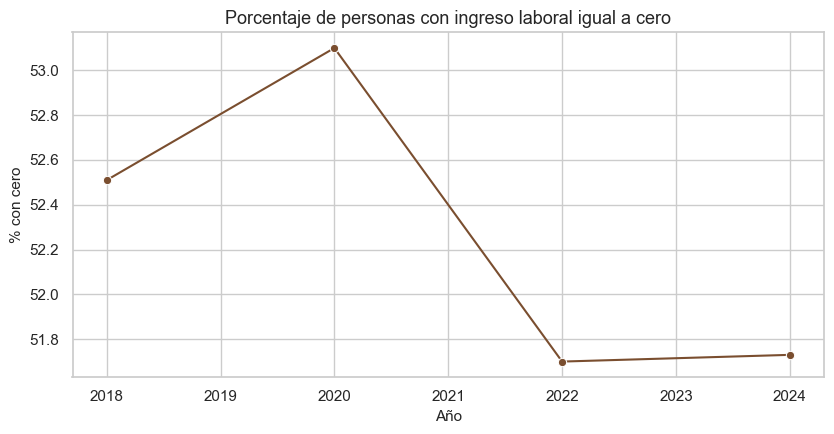

In [12]:
def labor_zero_by(control):
    tbl = persona.groupby(control, dropna=False, observed=False)[TARGET_LABOR].agg(N="size", cero=lambda s:int(s.eq(0).sum()), positivo=lambda s:int(s.gt(0).sum()), missing=lambda s:int(s.isna().sum())).reset_index()
    tbl["cero_pct"] = (tbl["cero"] / tbl["N"] * 100).round(2)
    return tbl.sort_values("cero_pct", ascending=False)

for control in ["anio","grupo_edad","sexo_desc","region_banxico","tam_loc_desc","est_socio_desc","tiene_trabajo_reportado"]:
    display(Markdown(f"### Ingreso laboral cero por {control}")); display(labor_zero_by(control))
fig, ax = plt.subplots(figsize=(8.5,4.5))
sns.lineplot(data=labor_zero_by("anio"), x="anio", y="cero_pct", marker="o", ax=ax, color="#7A4E2F")
ax.set_title("Porcentaje de personas con ingreso laboral igual a cero"); ax.set_xlabel("Año"); ax.set_ylabel("% con cero")
fig.tight_layout(); display(fig); plt.close(fig)

## Resolucion de pendientes de calidad

Se documentan las dos correcciones acotadas antes de avanzar: la etiqueta dañada de asistencia escolar en 2020/2022 y los 250 `NaN` del contador de personas con registros de ingreso en hogares. La validacion usa codigos y llaves ya presentes en las bases analiticas.

In [13]:
HOUSE_KEY = ["anio", "folioviv", "foliohog"]
asis_tmp = persona[["anio", "asis_esc", "asis_esc_desc", "nivel_desc"]].copy()
asis_tmp["asis_esc_codigo"] = asis_tmp["asis_esc"].astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
asis_validacion = (
    asis_tmp.groupby(["anio", "asis_esc_codigo", "asis_esc_desc"], dropna=False)
    .size()
    .reset_index(name="personas")
    .sort_values(["anio", "asis_esc_codigo", "asis_esc_desc"])
)

ingreso_hogar_calc = (
    persona.groupby(HOUSE_KEY, dropna=False)
    .agg(
        integrantes_calc=("numren", "size"),
        personas_con_registros_ingreso_calc=("registros_ingreso", lambda s: int((pd.to_numeric(s, errors="coerce").fillna(0) > 0).sum())),
        ingreso_personas_total_registros_tri_calc=(TARGET_PERSON_TOTAL, "sum"),
        ingreso_personas_laboral_negocio_tri_calc=(TARGET_LABOR, "sum"),
    )
    .reset_index()
)
contador_check = hogar[HOUSE_KEY + ["personas_con_registros_ingreso"]].merge(
    ingreso_hogar_calc,
    on=HOUSE_KEY,
    how="left",
    validate="1:1",
)
contador_check["diff_personas_con_registros"] = (
    contador_check["personas_con_registros_ingreso"] - contador_check["personas_con_registros_ingreso_calc"]
)
calidad_actualizacion = summary.get("calidad_actualizacion", {})
resolucion_pendientes = pd.DataFrame([
    {
        "pendiente": "asis_esc_desc",
        "evidencia": "El codigo 1 queda etiquetado como Si y el codigo 2 como No; el faltante restante corresponde a edades 0-5.",
        "decision": "Corregido por codigo documentado; usable en universo 6+.",
        "validacion": "No quedan categorias danadas para codigos 1/2.",
    },
    {
        "pendiente": "personas_con_registros_ingreso",
        "evidencia": f"NaN antes: {calidad_actualizacion.get('personas_con_registros_ingreso_nan_antes', 'no disponible')}; NaN despues: {int(hogar['personas_con_registros_ingreso'].isna().sum())}; maxima diferencia contra calculo desde personas: {float(contador_check['diff_personas_con_registros'].abs().max())}.",
        "decision": "Rellenado con 0 porque representa ausencia de registros individuales de ingreso, no perdida de llave hogar-persona.",
        "validacion": "Todos los hogares tienen integrantes en mart_persona y el contador coincide con el calculo reconstruido.",
    },
])
display(asis_validacion)
display(resolucion_pendientes)


,anio,asis_esc_codigo,asis_esc_desc,personas
0,2018,1,Sí,78198
1,2018,2,No,178627
2,2018,<NA>,NaN,12381
3,2020,1,Sí,87256
4,2020,2,No,215780
5,2020,<NA>,NaN,12707
6,2022,1,Sí,85012
7,2022,2,No,213200
8,2022,<NA>,NaN,11472
9,2024,1,Sí,83477


,pendiente,evidencia,decision,validacion
0,asis_esc_desc,El codigo 1 queda etiquetado como Si y el codi...,Corregido por codigo documentado; usable en un...,No quedan categorias danadas para codigos 1/2.
1,personas_con_registros_ingreso,NaN antes: 250; NaN despues: 0; maxima diferen...,Rellenado con 0 porque representa ausencia de ...,Todos los hogares tienen integrantes en mart_p...


## Faltantes por integración y variables con cautela

Las validaciones de la revisión 4 permiten distinguir faltantes derivados de merges opcionales. No se reconstruyen los merges; solo se usan los indicadores ya guardados.

In [14]:
merge_notes = pd.DataFrame([
    {"base":"Personas","origen":"ingresos.csv agregado a persona","match_pct":float(validacion_persona.loc[validacion_persona["paso"].str.contains("ingresos", case=False),"pct_match"].iloc[0]),"interpretacion":"Sin registro en ingresos.csv se conservan registros e ingresos agregados en 0; cero estructural del agregado."},
    {"base":"Personas","origen":"trabajos.csv agregado a persona","match_pct":float(validacion_persona.loc[validacion_persona["paso"].str.contains("trabajos", case=False),"pct_match"].iloc[0]),"interpretacion":"Caracteristicas laborales faltan para personas sin registro en trabajos.csv; restringir a trabajadores."},
    {"base":"Hogares","origen":"ingresos.csv agregado a hogar","match_pct":float(validacion_hogar.loc[validacion_hogar["paso"].str.contains("ingresos", case=False),"pct_match"].iloc[0]),"interpretacion":"Los 250 NaN previos de personas_con_registros_ingreso fueron validados contra mart_persona y rellenados con 0; el match opcional sigue documentando hogares sin registros en ingresos.csv."},
])
display(merge_notes)
problem_vars = pd.DataFrame([
    {"variable":"nivel_desc","problema":"Falta para quienes no asisten a la escuela","riesgo":"No mide escolaridad general.","decision_requerida":"Usar nivelaprob_desc para escolaridad general."},
    {"variable":"contrato_principal_desc","problema":"No aplica fuera de trabajadores que reciben pago","riesgo":"Sesgo si se usa sobre toda la poblacion o todos los trabajadores.","decision_requerida":"Definir universo de trabajadores con pago."},
])
display(problem_vars)


,base,origen,match_pct,interpretacion
0,Personas,ingresos.csv agregado a persona,66.0118,Sin registro en ingresos.csv se conservan regi...
1,Personas,trabajos.csv agregado a persona,48.0447,Caracteristicas laborales faltan para personas...
2,Hogares,ingresos.csv agregado a hogar,99.9276,Los 250 NaN previos de personas_con_registros_...


,variable,problema,riesgo,decision_requerida
0,nivel_desc,Falta para quienes no asisten a la escuela,No mide escolaridad general.,Usar nivelaprob_desc para escolaridad general.
1,contrato_principal_desc,No aplica fuera de trabajadores que reciben pago,Sesgo si se usa sobre toda la poblacion o todo...,Definir universo de trabajadores con pago.


## Calidad de variables candidatas

Resumen compacto para decidir uso provisional de variables. Esta tabla no elimina variables ni propone imputación.

In [15]:
quality_compact = mechanisms[["Base","Concepto","Variable","Missing total %","Ceros total %","Universo aplicable","Patrón probable","Clasificación de cero","Implicación"]].copy()
quality_compact = quality_compact.sort_values(["Base","Patrón probable","Missing total %"], ascending=[True, True, False])
display(quality_compact)

,Base,Concepto,Variable,Missing total %,Ceros total %,Universo aplicable,Patrón probable,Clasificación de cero,Implicación
25,Hogares,Ingreso corriente hogar,ing_cor_hogar_oficial_tri,0.000,0.010,todos_hogares,sin_faltantes,cero_legitimo_con_cautela,Usar directamente; ceros escasos con cautela.
26,Hogares,Ingreso laboral hogar,ingtrab_hogar_oficial_tri,0.000,11.629,todos_hogares,sin_faltantes,cero_legitimo,Distinguir hogares con/sin ingreso laboral.
27,Hogares,Ingreso corriente pc,ing_cor_pc_oficial_tri,0.000,0.010,todos_hogares,sin_faltantes,cero_legitimo_con_cautela,Usar como target territorial de hogar.
28,Hogares,Personas con registros ingreso,personas_con_registros_ingreso,0.000,0.072,todos_hogares,sin_faltantes,cero_estructural,Usar como conteo derivado; cero significa ause...
29,Hogares,Tamaño hogar,tot_integ,0.000,0.000,todos_hogares,sin_faltantes,no_aplica,Usar directamente.
30,Hogares,Ocupados hogar,ocupados,0.000,10.818,todos_hogares,sin_faltantes,cero_legitimo,Usar directamente.
31,Hogares,Jefatura sexo,sexo_jefe_desc,0.000,0.000,todos_hogares,sin_faltantes,no_aplica,Usar directamente.
32,Hogares,Jefatura educación,nivelaprob_jefe_desc,0.000,0.000,todos_hogares,sin_faltantes,no_aplica,Usar directamente.
33,Hogares,Región Banxico,region_banxico,0.000,0.000,todos_hogares,sin_faltantes,no_aplica,Usar directamente.
34,Hogares,Factor expansión,factor,0.000,0.000,todos_hogares,sin_faltantes,no_aplica,Usar para descriptivos ponderados; diseño comp...


## Nota sobre MCAR, MAR, MNAR y pruebas auxiliares

En esta etapa no se afirma que una variable “sea MCAR” o “sea MAR” de forma definitiva. Primero se revisaron universos de aplicación y saltos lógicos. Los faltantes mas grandes se explican por diseno del cuestionario o por universos aplicables ya documentados; los dos pendientes acotados de calidad quedaron resueltos antes de avanzar.

No se ejecuta Little's MCAR test porque no hay una implementación confiable disponible en el entorno y no se instalarán paquetes adicionales. Tampoco se ajusta una regresión logística auxiliar: después de restringir universos, no quedan variables centrales con missing residual suficientemente grande que justifique modelar la probabilidad de falta. Esto puede reabrirse si una variable problemática se vuelve indispensable.

## Conclusiones operativas para la siguiente etapa

- La base analítica de personas tiene una fila por persona x año y la base analítica de hogares una fila por hogar x año.
- Las bases concatenan levantamientos independientes: 2018, 2020, 2022 y 2024.
- Geografía, estratos y diseño muestral están completos en las variables prioritarias.
- Los faltantes grandes en variables laborales son principalmente estructurales.
- El ingreso laboral tiene muchos ceros legítimos; conviene separar presencia de ingreso laboral positivo y monto condicionado a ingreso > 0.
- No se imputó, no se eliminaron filas, no se modificaron datos raw y no se reconstruyeron bases.